In [8]:
import pandas as pd
import numpy as np

fsd = pd.read_csv("marks/Compile_Marksheet_SEM_IV_CE_IT_2026_T1_FSD_II.csv")
df = pd.DataFrame(fsd)
df = df.iloc[8:]
df.head(50)
toc = pd.read_csv("marks/Compile_Marksheet_SEM_IV_CE_IT_2026_T1_TOC_compressed.csv")
df1 = pd.DataFrame(toc)
df1 = df1.iloc[8:]
df1.head(50)

df2  = df["Unnamed:8"] + df1                                                                                                                                                                                                                                                                        

,Unnamed: 0,Unnamed: 1,"L J INSTITUTE OF ENGINEERING AND TECHNOLOGY, AHMEDABAD",Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
8,1,SY-1,CE,5,24002170110071,A1,KAKANI NIHARKUMAR KISHORBHAI,KMS,25
9,1,SY-1,CE,1,24002170110144,A1,PATEL MITESH GHANSHYAMBHAI,PHA,25
10,1,SY-1,CE,60,24002170110171,A2,SHETH YUG MITULKUMAR,DPB,25
11,1,SY-2,CSE,63,24002171210152,B2,RAOL YUVRAJSINH PRADYUMANSINH,DPS,25
12,1,SY-3,CSD,26,24002170310010,C1,LABBAI MOHAMED ABDULLA JAFAR SADIK,DRM,25
13,1,SY-3,CSE_AI,3,24002171710013,C1,LATHIYA MANTHAN RAJESHBHAI,BNS,25
14,1,SY-4,CST,1,24002171310074,D1,MALAY CHHATBAR,DAM,25
15,1,SY-4,MA & CP,3,24002171610013,D1,PATEL KASHYAPKUMAR ARVINDBHAI,PKP,25
16,9,SY-2,CSE,136,25002171220011,B4,KANTARIYA ADITYA JAYENDRABHAI,VBY,24.5
17,9,SY-3,IT,7,24002170210098,C1,RATHOD MIHIR MAHENDRABHAI,JDP,24.5


In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import seaborn as sns

In [12]:
df = pd.DataFrame(pd.read_csv("Datasets/Fish.csv"))
df

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df = df.drop("Species",axis=1)

In [15]:
x = df[['Length1']]
y = df[['Weight']]

In [16]:
print(x,y)

     Length1
0       23.2
1       24.0
2       23.9
3       26.3
4       26.5
..       ...
154     11.5
155     11.7
156     12.1
157     13.2
158     13.8

[159 rows x 1 columns]      Weight
0     242.0
1     290.0
2     340.0
3     363.0
4     430.0
..      ...
154    12.2
155    13.4
156    12.2
157    19.7
158    19.9

[159 rows x 1 columns]


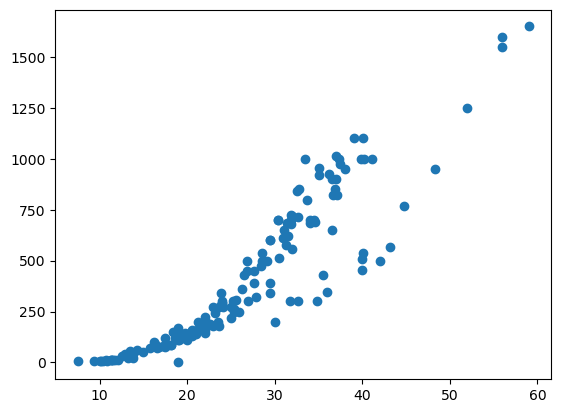

In [18]:
plt.scatter(x,y)

In [45]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=10)

In [47]:
x_train

,Length1
124,39.8
49,22.0
68,19.8
2,23.9
59,33.7
...,...
113,34.0
64,17.5
15,29.4
125,40.1


In [31]:
x_test

,Length1
35,12.9
85,19.3
47,21.1
24,31.9
129,31.7
95,21.5
128,30.0
10,28.4
58,28.5
104,25.4


In [52]:
model = LinearRegression()

In [53]:
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [54]:
y_pred = model.predict(x_test)

In [61]:
y_pred[15]

array([-89.02206056])

In [62]:
model.coef_

array([[33.26117473]])

In [63]:
model.intercept_

array([-464.87333499])

In [64]:
pd.DataFrame({
    "actual_data":y_test.squeeze(),
    "prediceted_data":y_pred.squeeze()
})

,actual_data,prediceted_data
35,40.0,-35.804181
85,130.0,177.067337
47,160.0,236.937452
24,700.0,596.158139
129,300.0,589.505904
95,170.0,250.241922
128,200.0,532.961907
10,475.0,479.744027
58,540.0,483.070145
104,265.0,379.960503


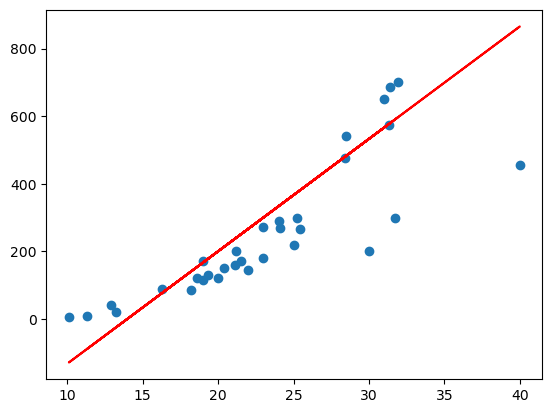

In [68]:
plt.scatter(x_test,y_test,label="Actual Data")
plt.plot(x_test,y_pred,label='Predected Data',color= 'red')

In [70]:
mean_squared_error(y_test,y_pred)

16917.312221946187

In [72]:
mean_absolute_error(y_test,y_pred)

93.87412129033645

In [73]:
r2_score(y_test,y_pred)

0.558839021555892

In [75]:
x_test=[[25]]

In [76]:
# y = mx + b
y_new_pred = model.coef_ * x_test + model.intercept_

In [77]:
y_new_pred

array([[366.65603321]])

In [79]:
y_new_pred = model.predict(x_test)
y_new_pred

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[366.65603321]])

In [101]:
# test size = 0.1,0.2,0.3,0.4,0.5
val = [0.1,0.2,0.3,0.4,0.5]
mean =[]
res = []
for i in val:
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=i,random_state=10)
    #model1 = LinearRegression()
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    mean.append(mean_squared_error(y_test,y_pred))
    res.append(r2_score(y_test,y_pred))

print(res.index(min(res)),min(res),mean.index(min(mean)),min(mean))
print(res.index(max(res)),max(res),mean.index(max(mean)),max(mean))

1 0.558839021555892 0 15523.565250616111
4 0.7474337483186893 2 21829.068497661665


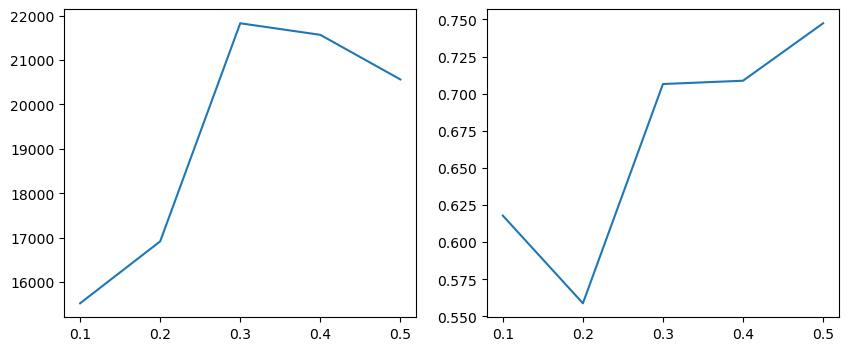

In [113]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(val,mean)
plt.subplot(1,2,2)
plt.plot(val,res)


In [119]:
x = df.drop('Weight',axis=1)


In [120]:
y = df[['Weight']]

In [118]:

df.corr(numeric_only=True)

,Weight,Length1,Length2,Length3,Height,Width
Weight,1.000000,0.915712,0.918618,0.923044,0.724345,0.886507
Length1,0.915712,1.000000,0.999517,0.992031,0.625378,0.867050
Length2,0.918618,0.999517,1.000000,0.994103,0.640441,0.873547
Length3,0.923044,0.992031,0.994103,1.000000,0.703409,0.878520
Height,0.724345,0.625378,0.640441,0.703409,1.000000,0.792881
Width,0.886507,0.867050,0.873547,0.878520,0.792881,1.000000


<Axes: >

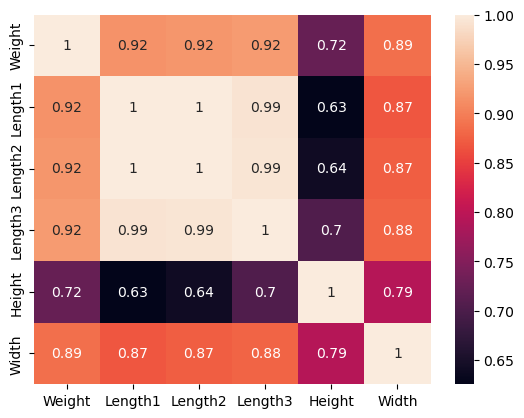

In [122]:
sns.heatmap(df.corr(),annot=True)

In [123]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=20)

In [126]:
y_train.shape

(127, 1)

In [130]:
y_test

,Weight
147,7.0
57,306.0
98,188.0
88,130.0
135,510.0
34,950.0
87,120.0
143,1550.0
55,270.0
107,300.0


In [129]:
x_test

,Length1,Length2,Length3,Height,Width
147,10.1,10.6,11.6,1.7284,1.1484
57,25.6,28.0,30.8,8.7780,4.6816
98,22.6,24.6,26.2,6.7334,4.1658
88,20.0,22.0,23.5,6.1100,3.5250
135,40.0,42.5,45.5,6.8250,4.4590
34,38.0,41.0,46.5,17.6235,6.3705
87,20.0,22.0,23.5,5.6400,3.5250
143,56.0,60.0,64.0,9.6000,6.1440
55,23.6,26.0,28.7,8.3804,4.2476
107,26.9,28.7,30.1,7.5852,4.6354


In [131]:
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [132]:
y_pred = model.predict(x_test)

array([-83.8416243])